In [1]:
import sys, os
sys.path.insert(1, os.path.realpath(os.path.pardir))
from specs import *
import readdata
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import t
from matplotlib.transforms import ScaledTranslation
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

# rawDir = "../../../data/"
# pn1Dir = rawDir + "P1_SN1222/"
# pn2Dir = rawDir + "P2_SN1215/"
# pn1files0 = [f for f in listdir(pn1Dir) if isfile(join(pn1Dir, f)) and f.endswith('mca')]
# pn2files0 = [f for f in listdir(pn2Dir) if isfile(join(pn2Dir, f)) and f.endswith('mca')]

# pn1files = [None] * len(pn1files0)
# pn2files = [None] * len(pn2files0)

# for f1 in pn1files0:
#     ddd = (f1[1:-4].split("_"))[-1]
#     if ddd == "BKG":
#         pn1files[0] = pn1Dir+f1
#     else :
#         q = int(ddd.split("-")[-1])
#         pn1files[q] = pn1Dir+f1
# for f2 in pn2files0:
#     ddd = (f2[1:-4].split("_"))[-1]
#     if ddd == "BKG":
#         pn2files[0] = pn2Dir+f2
#     else :
#         q = int(ddd.split("-")[-1])
#         pn2files[q] = pn2Dir+f2


# Log =[
#     [0, ["Bkg"], 0, 0],                            # 0
#     [1, ["Am241",], 80, 420],                      # 1
#     [2, ["Am241",], 180, 320],                     # 2
#     [3, ["Am241",], 280, 220],                     # 3
#     [4, ["Am241",], 460, 40],                      # 4
#     [5, ["Cs137",], 70, 430],                      # 5
#     [6, ["Cs137",], 130, 370],                     # 6
#     [7, ["Cs137",], 300, 200],                     # 7
#     [8, ["Cs137",], 390, 110],                     # 8
#     [9, ["Co60",], 60, 440],                       # 9
#     [10, ["Co60",], 120, 380],                      # 10
#     [11, ["Co60",], 310, 190],                      # 11
#     [12, ["Co60",], 470, 30],                       # 12
#     [13, ["Co60", "Cs137"], 136, 359],              # 13
#     [14, ["Am241", "Co60"], 287, 208],              # 14
#     [15, ["Co60", "Cs137"], 361, 134],              # 15
#     [16, ["Am241", "Cs137"], 163, 332],
#     [17, ["Am241", "Co60", "Cs137"], 309, 186],
#     [18, ["Am241", "Co60",], 210, 285, 153, 342],
#     [19, ["Co60", "Cs137"], 285, 210, 367, 128],
#     [20, ["Am241", "Cs137"], 85, 410, 173, 322],
#     [21, ["Co60", "Cs137"], 316, 179, 223, 272],
#     [22, [None,], ],
# ]



# speckeys = [
#     "bkg" ,
#     "am_80" ,
#     "am_180" ,
#     "am_280" ,
#     "am_460" ,
#     "cs_70" ,
#     "cs_130" ,
#     "cs_300" ,
#     "cs_390" ,
#     "co_60" ,
#     "co_120" ,
#     "co_310" ,
#     "co_470" ,
#     "co_cs_136",
#     "am_co_287" ,
#     "co_cs_361" ,
#     "am_cs_163" ,
#     "am_co_cs_309" ,
#     "am_210_co_153" ,
#     "co_285_cs_367" ,
#     "am_85_cs_173" ,
#     "co_223_cs_316" ]


# HeaderInfo={}
# for path in pn1files0:
#     lines = [l.strip() for l in open(os.path.join(pn1Dir,path), encoding='latin-1').read().splitlines()]
#     qs = (path.split("_")[-1]).split(".")[0]
#     if qs == "BKG":
#         id = 0
#     else :
#         id = int(qs.split("-")[-1])
    
#     def hdr(key):
#         for l in lines:
#             if l.startswith(key):
#                 return l.split('-', 1)[1].strip()
#         return ''
#     def status(key):
#         for l in lines:
#             if l.strip().startswith(key):
#                 return l.split(':', 1)[1].strip()
#         return ''
#     def cfg(key):
#         for l in lines:
#             if l.startswith(key + '='):
#                 return l.split('=', 1)[1].split(';')[0]
#         return ''
#     if id < 22 :
#         HeaderInfo[speckeys[id]] ={
#             "LIVE_TIME" : hdr('LIVE_TIME'), 
#             "REAL_TIME" : hdr('REAL_TIME'), 
#             "START_TIME" : hdr('START_TIME'),
#             "Fast Count" : status('Fast Count'), 
#             "Slow Count" : status('Slow Count'), 
#             "Dead Time" : status('Dead Time'),
#             "MCAC" : cfg('MCAC'), 
#             "GAIN" : cfg('GAIN'), 
#             "THFA" : cfg('THFA'), 
#             "THSL" : cfg('THSL')
#         }
    
# # PN1 data

# ni = 3
# Specs1 = pd.DataFrame( {
#     "bkg" : read_mca(pn1files[0])[ni:], 
#     "am_80" : read_mca(pn1files[1])[ni:],
#     "cs_70" : read_mca(pn1files[5])[ni:],
#     "cs_130" : read_mca(pn1files[6])[ni:],
#     "co_120" : read_mca(pn1files[10])[ni:],
#     "co_60" :  read_mca(pn1files[9])[ni:],
#     "co_cs_136" : read_mca(pn1files[13])[ni:],
#     "am_co_287" : read_mca(pn1files[14])[ni:],
#     "co_cs_361" : read_mca(pn1files[15])[ni:],
#     "am_cs_163" : read_mca(pn1files[16])[ni:],
#     "am_co_cs_309" : read_mca(pn1files[17])[ni:],
#     "am_210_co_153" : read_mca(pn1files[18])[ni:],
#     "co_285_cs_367" : read_mca(pn1files[19])[ni:],
#     "am_85_cs_173" : read_mca(pn1files[20])[ni:],
#     "co_316_cs_223" : read_mca(pn1files[21])[ni:]
        
# })

# # PN2 data
# Specs2 = pd.DataFrame( {
#     "bkg" : read_mca(pn2files[0])[ni:], 
#     "am_80" : read_mca(pn2files[1])[ni:],
#     "cs_70" : read_mca(pn2files[5])[ni:],
#     "cs_130" : read_mca(pn2files[6])[ni:],
#     "co_120" : read_mca(pn2files[10])[ni:],
#     "co_60" :  read_mca(pn2files[9])[ni:],
#     "co_cs_136" : read_mca(pn2files[13])[ni:],
#     "am_co_287" : read_mca(pn2files[14])[ni:],
#     "co_cs_361" : read_mca(pn2files[15])[ni:],
#     "am_cs_163" : read_mca(pn2files[16])[ni:],
#     "am_co_cs_309" : read_mca(pn2files[17])[ni:],
#     "am_210_co_153" : read_mca(pn2files[18])[ni:],
#     "co_285_cs_367" : read_mca(pn2files[19])[ni:],
#     "am_85_cs_173" : read_mca(pn2files[20])[ni:],
#     "co_316_cs_223" : read_mca(pn2files[21])[ni:]
        
# })

# SpecsRef = pd.DataFrame( {
#     "bkg" : read_mca(pn1files[0])[ni:], 
#     "am_80" : read_mca(pn1files[1])[ni:],
#     "am_180" : read_mca(pn1files[2])[ni:],
#     "am_280" : read_mca(pn1files[3])[ni:],
#     "am_460" : read_mca(pn1files[4])[ni:],
#     "co_60" :  read_mca(pn1files[9])[ni:],
#     "co_120" :  read_mca(pn1files[10])[ni:],
#     "co_310" :  read_mca(pn1files[11])[ni:],
#     "co_470" :  read_mca(pn1files[12])[ni:],
#     "cs_70" :  read_mca(pn1files[5])[ni:],
#     "cs_130" :  read_mca(pn1files[6])[ni:],
#     "cs_300" :  read_mca(pn1files[7])[ni:],
#     "cs_390" :  read_mca(pn1files[8])[ni:],
    
# })

# for kk in SpecsRef.keys():
#     SpecsRef[kk] = SpecsRef[kk]/float(HeaderInfo[kk]["LIVE_TIME"])

# _rr = {}
# for kk in SpecsRef.keys():
#     if kk != 'bkg':
#         _rr[kk] = SpecsRef[kk] - SpecsRef['bkg']
# SpecsRefBkg = pd.DataFrame(_rr)
SpecsRefBkg = readdata.read_refs()

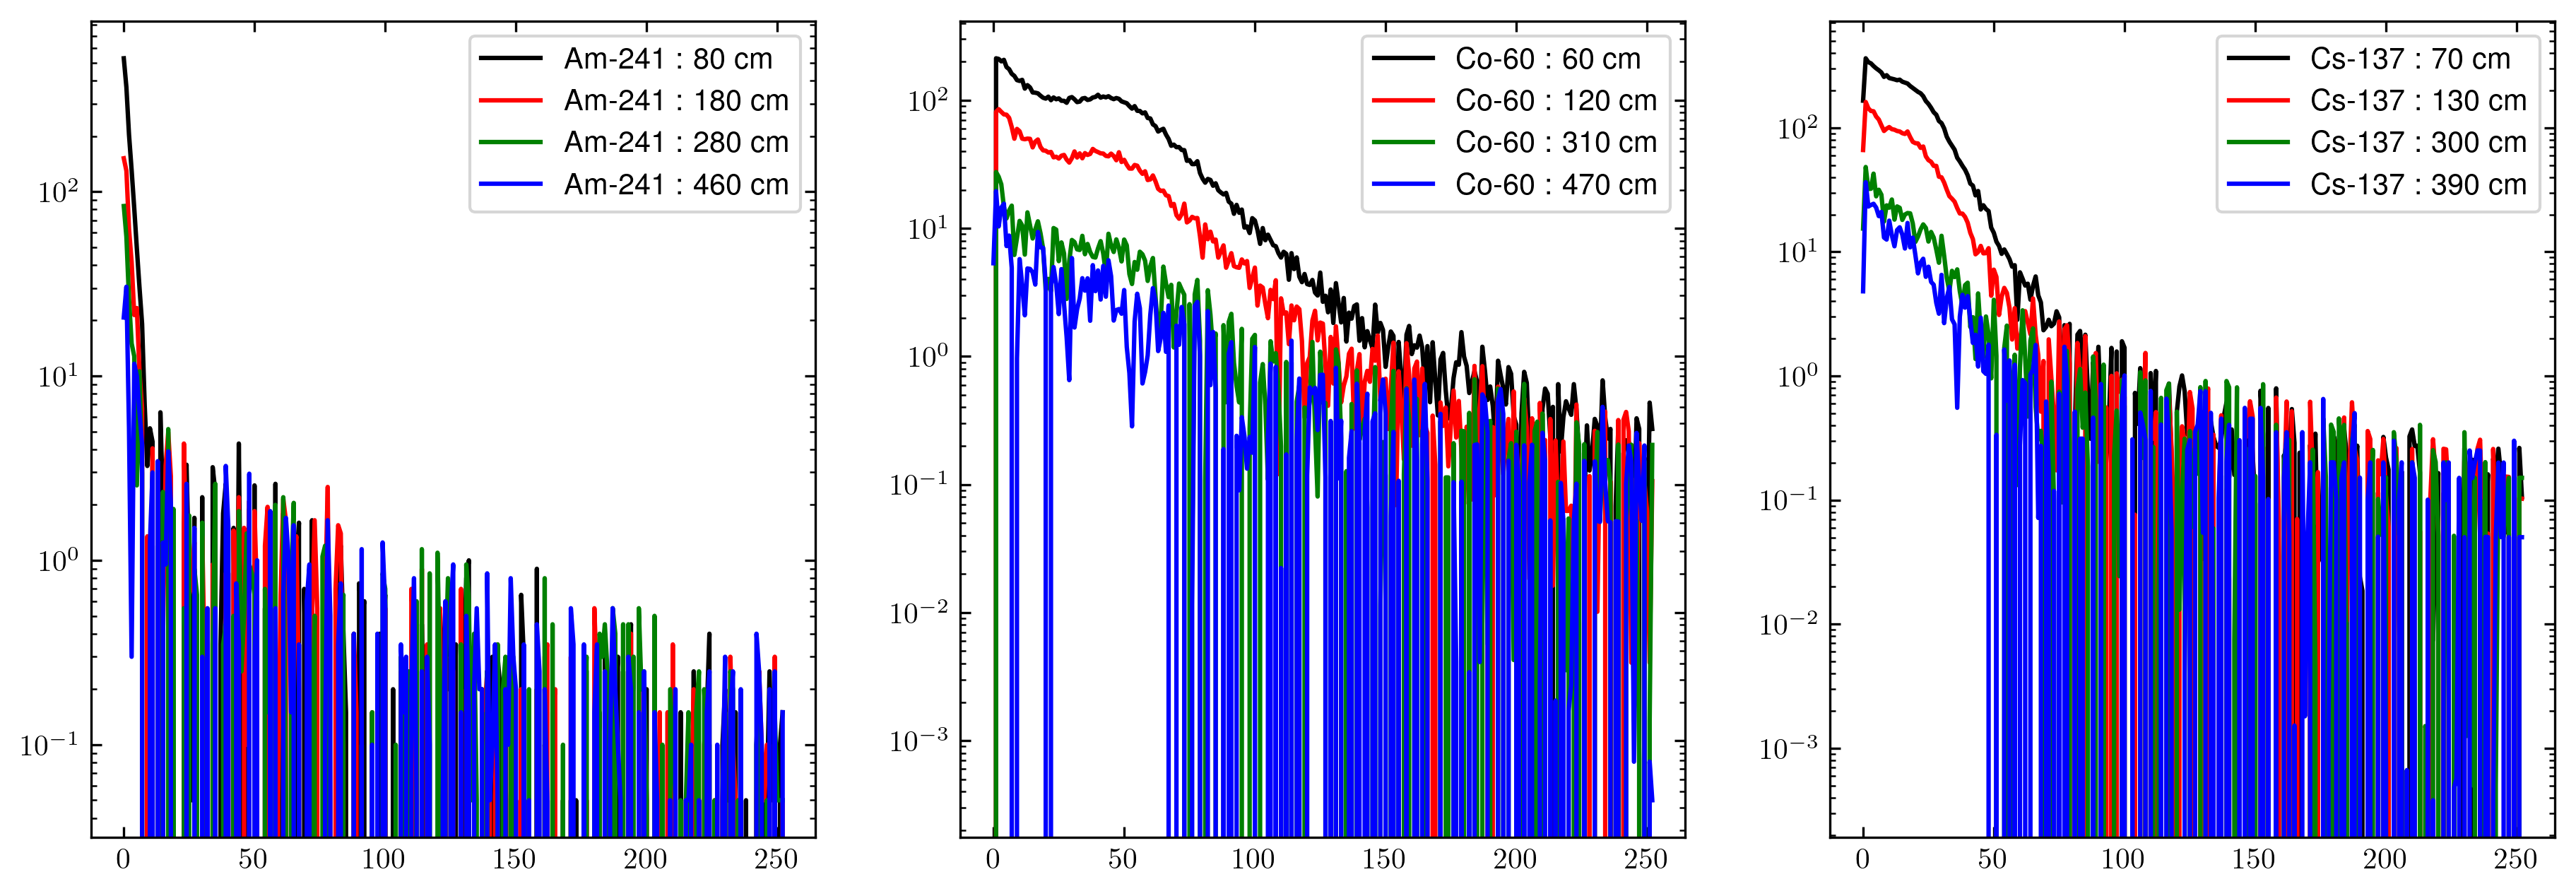

In [2]:
plt.figure(figsize=(15, 5), dpi=300)

plt.subplot(131)
plt.plot(SpecsRefBkg['am_80'] ,color="black", label = "Am-241 : 80 cm" )
plt.plot(SpecsRefBkg['am_180'], color="red", label = "Am-241 : 180 cm")
plt.plot(SpecsRefBkg['am_280'], color = "green", label = "Am-241 : 280 cm" )
plt.plot(SpecsRefBkg['am_460'], color="blue", label = "Am-241 : 460 cm" )
plt.semilogy()
plt.legend()

plt.subplot(132)
plt.plot(SpecsRefBkg['co_60']  ,color="black", label = "Co-60 : 60 cm" )
plt.plot(SpecsRefBkg['co_120'] ,color="red", label = "Co-60 : 120 cm")
plt.plot(SpecsRefBkg['co_310'] ,color="green", label = "Co-60 : 310 cm")
plt.plot(SpecsRefBkg['co_470'] ,color="blue", label = "Co-60 : 470 cm")
plt.semilogy()
plt.legend()

plt.subplot(133)
plt.plot(SpecsRefBkg['cs_70']  ,color="black", label = "Cs-137 : 70 cm" )
plt.plot(SpecsRefBkg['cs_130'] ,color="red", label = "Cs-137 : 130 cm")
plt.plot(SpecsRefBkg['cs_300'] ,color="green", label = "Cs-137 : 300 cm")
plt.plot(SpecsRefBkg['cs_390'] ,color="blue", label = "Cs-137 : 390 cm")
plt.semilogy()
plt.legend()

In [3]:
print("| %8s | %13s | %9s | %18s | %10s | %15s |"%("Isotope", "Distance (cm)", "(d_0/d)^2", "Solid angle ratio", "Count sum", "Count sum ratio"))
for kk in SpecsRefBkg.keys():
    xs = kk.split("_")
    nn, d = (xs[0], int(xs[1]))
    if nn == "am" :
        specsum = sum(SpecsRefBkg[kk])/sum(SpecsRefBkg["am_80"])
        sangle = solidangle(d)/solidangle(80)
        invdsq = (80/d)**2
    elif nn == "co" :
        specsum = sum(SpecsRefBkg[kk])/sum(SpecsRefBkg["co_60"])
        sangle = solidangle(d)/solidangle(60)
        invdsq = (60/d)**2
    elif nn == "cs" :
        specsum = sum(SpecsRefBkg[kk])/sum(SpecsRefBkg["cs_70"])
        sangle = solidangle(d)/solidangle(70)
        invdsq = (70/d)**2
    
    
    print("| %8s | %13d | %9.6f | %18.8f | %10d | %15.5f |"%(nn, d, invdsq, sangle, sum(SpecsRefBkg[kk]), specsum))
    
    
    

|  Isotope | Distance (cm) | (d_0/d)^2 |  Solid angle ratio |  Count sum | Count sum ratio |
|       am |            80 |  1.000000 |         1.00000000 |       1434 |         1.00000 |
|       am |           180 |  0.197531 |         0.26840164 |        464 |         0.32360 |
|       am |           280 |  0.081633 |         0.11822422 |        197 |         0.13761 |
|       am |           460 |  0.030246 |         0.04518151 |         64 |         0.04502 |
|       co |            60 |  1.000000 |         1.00000000 |       8206 |         1.00000 |
|       co |           120 |  0.250000 |         0.36604683 |       3018 |         0.36779 |
|       co |           310 |  0.037461 |         0.06613354 |        588 |         0.07175 |
|       co |           470 |  0.016297 |         0.02943696 |        292 |         0.03562 |
|       cs |            70 |  1.000000 |         1.00000000 |       8066 |         1.00000 |
|       cs |           130 |  0.289941 |         0.39242688 |       31

In [4]:
def Omega(d=80):
    a=90.0
    b=15.0
    return 4*np.arcsin(a*b/np.sqrt((a**2+d**2)*((b**2+d**2))))

In [5]:
Omega(470)/Omega(60)

np.float64(0.029524453052047893)

| RadionuRadionuclide | Distance (cm)  | Inverse-square estimate | Finite-detector solid-angle estimate | Normalized measured  response | Top-rank stability (%)  |
|:---------|:---------:|:---------:|:---------:|:---------:|:---------:|
| Am-241 | 80 | 1.000  | 1.000  | 1.000  | 100.00 | 
| Am-241| 180 |  0.198 |  0.269  | 0.316 |  100.00 |
| Am-241 | 280 | 0.082 | 0.118 | 0.129  | 100.00  |
| Am-241 | 460 | 0.030  | 0.045 | 0.042  | 96.86 | 
| Cs-137 | 70  | 3.449 | 2.545  | 2.581  | 100.00  | 
| Cs-137 | 130 | 1.000  | 1.000  | 1.000  | 100.00  | 
| Cs-137 | 300 |  0.188 | 0.220 | 0.220  | 100.00  | 
| Cs-137 | 390 |  0.111  | 0.132 | 0.128  | 99.84 | 
| Co-60 | 60 | 4.000 | 2.728 | 2.763 | 100.00 |
| Co-60 | 120 | 1.000 |  1.000 | 1.000 | 100.00 | 
| Co-60 | 310  | 0.150 |  0.181 |  0.183 | 100.00 |
| Co-60 | 470 | 0.065 | 0.081 | 0.074 | 99.84 | 

| RadionuRadionuclide | Distance (cm)  | Inverse-square estimate | Finite-detector solid-angle estimate | Normalized measured  response |
|:---------|:---------:|:---------:|:---------:|:---------:|
| Am-241 | 80 | 1.000  | 1.000  | 1.000  | 
| Am-241| 180 |  0.198 |  0.269  | 0.316 | 
| Am-241 | 280 | 0.082 | 0.118 | 0.129  | 
| Am-241 | 460 | 0.030  | 0.045 | 0.042  | 
| Cs-137 | 70  | 3.449 | 2.545  | 2.581  | 
| Cs-137 | 130 | 1.000  | 1.000  | 1.000  | 
| Cs-137 | 300 |  0.188 | 0.220 | 0.220  | 
| Cs-137 | 390 |  0.111  | 0.132 | 0.128  | 
| Co-60 | 60 | 4.000 | 2.728 | 2.763 | 
| Co-60 | 120 | 1.000 |  1.000 | 1.000 | 
| Co-60 | 310  | 0.150 |  0.181 |  0.183 | 
| Co-60 | 470 | 0.065 | 0.081 | 0.074 |

In [6]:
def Omega(d):
    a=90.0
    b=15.0
    return 4*np.arcsin(a*b/np.sqrt)

In [7]:
_bccsref = {}
for kk in SpecsRefBkg.keys():
    _bccsref[kk] = bccs(SpecsRefBkg[kk])

BCCSRef = pd.DataFrame(_bccsref)

In [8]:
_refspecs =_refspecSub= {"Am" : BCCSRef["am_80"], "Co" :BCCSRef["co_60"], "Cs":BCCSRef["cs_70"]}

dx0 ={ "am": 80, "co":60, "cs": 70}

BCCSFitResult0, BCCSFitResult = {}, {}

for kk in BCCSRef.keys():
    popt, se, pconv = BCCSfit((0.5, 0.5, 0.5), BCCSRef[kk], _refspecSub, 150, False)
    BCCSFitResult0[kk] = (popt, se, pconv)
    BCCSFitResult[kk] = {}
    BCCSFitResult[kk]["am"] = [float(c) for c in (float(popt[0]), float(np.sqrt(se[0])))]
    BCCSFitResult[kk]["co"] = [float(c) for c in (float(popt[1]), float(np.sqrt(se[1])))]
    BCCSFitResult[kk]["cs"] = [float(c) for c in (float(popt[2]), float(np.sqrt(se[2])))]

In [9]:
SpecsRefBkg["am_80"]

0      528.10
1      367.60
2      203.05
3      130.40
4       81.15
        ...  
248      0.05
249      0.25
250     -0.10
251      0.10
252      0.15
Name: am_80, Length: 253, dtype: float64

In [14]:
print("| %12s | %13s | %9s | %9s | %9s | %14s | %14s | %14s |"%("Isotope", "distance (cm)", "(d_0/d)^2", "S_r", "Sum ratio", "Am-241", "Co-60", "Cs-137"))
for kk in BCCSFitResult.keys():
    
    nn, d0 = kk.split("_")
    dd = int(d0)
    
    print("| %12s | %13d | %9.3f | %9.3f | %9.3f | %6.3f(%6.3f) | %6.3f(%6.3f) | %6.3f(%6.3f) |"%(nn, dd, (dx0[nn]/dd)**2, solidangle(dd)/solidangle(dx0[nn]), sum(SpecsRefBkg[kk])/sum(SpecsRefBkg[nn+"_"+"%d"%dx0[nn]]), BCCSFitResult[kk]["am"][0], BCCSFitResult[kk]["am"][1], BCCSFitResult[kk]["co"][0], BCCSFitResult[kk]["co"][1], BCCSFitResult[kk]["cs"][0], BCCSFitResult[kk]["cs"][1]))

|      Isotope | distance (cm) | (d_0/d)^2 |       S_r | Sum ratio |         Am-241 |          Co-60 |         Cs-137 |
|           am |            80 |     1.000 |     1.000 |     1.000 |  1.000( 0.023) | -0.000( 0.006) |  0.000( 0.008) |
|           am |           180 |     0.198 |     0.268 |     0.324 |  0.316( 0.025) |  0.002( 0.006) | -0.000( 0.007) |
|           am |           280 |     0.082 |     0.118 |     0.138 |  0.137( 0.034) | -0.000( 0.006) | -0.000( 0.009) |
|           am |           460 |     0.030 |     0.045 |     0.045 |  0.052( 0.024) |  0.000( 0.002) |  0.000( 0.005) |
|           co |            60 |     1.000 |     1.000 |     1.000 |  0.000( 0.018) |  1.000( 0.005) | -0.000( 0.006) |
|           co |           120 |     0.250 |     0.366 |     0.368 |  0.011( 0.027) |  0.352( 0.008) |  0.016( 0.010) |
|           co |           310 |     0.037 |     0.066 |     0.072 |  0.031( 0.027) |  0.064( 0.008) |  0.003( 0.010) |
|           co |           470 |     0.0

In [11]:
BCCSFitResult

{'am_80': {'am': [0.999999998806916, 0.023384680472233976],
  'co': [-7.680369182879571e-13, 0.006055514705769809],
  'cs': [5.89795506752472e-12, 0.00760765828186182]},
 'am_180': {'am': [0.31601167792466084, 0.025287979104685034],
  'co': [0.0019687511917255035, 0.0062331070089133075],
  'cs': [-1.583213680456477e-10, 0.006748756098323023]},
 'am_280': {'am': [0.137164050296861, 0.03433379575674557],
  'co': [-3.2229421959871857e-11, 0.006468938869950074],
  'cs': [-7.970762303961997e-11, 0.008646659545390366]},
 'am_460': {'am': [0.05159079652586424, 0.02363891740665856],
  'co': [1.8354055207992505e-12, 0.0024661836944267265],
  'cs': [1.1103483721538294e-11, 0.004778795443445595]},
 'co_60': {'am': [2.0237971523584274e-08, 0.01843891528891964],
  'co': [0.999999997424192, 0.00530965149773577],
  'cs': [-3.7143947605239463e-09, 0.005760435721410893]},
 'co_120': {'am': [0.010941213270569405, 0.02698128494344118],
  'co': [0.3516590393695661, 0.00793899321506506],
  'cs': [0.0164388

In [12]:
dx0

{'am': 80, 'co': 60, 'cs': 70}

In [22]:
A=np.array([BCCSRef["am_80"][0:147], BCCSRef["co_60"][0:147], BCCSRef["cs_70"][0:147]])

In [23]:
A

array([[ 1.43480000e+03,  9.06700000e+02,  5.39100000e+02,
         3.36050000e+02,  2.05650000e+02,  1.24500000e+02,
         7.55000000e+01,  4.52500000e+01,  2.61000000e+01,
         1.92000000e+01,  1.59500000e+01,  1.07500000e+01,
         6.35000000e+00,  9.45000000e+00,  1.14000000e+01,
         5.05000000e+00,  3.15000000e+00, -3.00000000e-01,
        -1.70000000e+00, -1.40000000e+00, -2.10000000e+00,
        -8.00000000e-01,  1.55000000e+00,  4.00000000e+00,
         2.40000000e+00, -9.00000000e-01, -1.70000000e+00,
        -1.75000000e+00, -3.45000000e+00, -2.30000000e+00,
        -6.00000000e-01, -2.80000000e+00, -2.00000000e+00,
         4.00000000e-01,  2.50000000e+00, -7.00000000e-01,
        -3.05000000e+00, -1.60000000e+00, -1.95000000e+00,
        -3.75000000e+00, -6.35000000e+00, -5.95000000e+00,
        -4.15000000e+00, -5.65000000e+00, -5.70000000e+00,
        -1.00000000e+01, -1.02000000e+01, -9.65000000e+00,
        -1.03500000e+01, -1.22500000e+01, -1.06500000e+0

In [24]:
print(A.shape, np.linalg.cond(A))

(3, 147) 33.62752018860155


In [25]:
A_norm = A / np.max(np.abs(A), axis=0)
print(np.linalg.cond(A_norm))

60.105539955423005


In [28]:
from scipy.optimize import nnls

def BCCSfit(spectrum, refspecs, idf=None):
    if idf is None:
        idf = len(spectrum)
    A = np.column_stack([refspecs["Am"][:idf],
                         refspecs["Co"][:idf],
                         refspecs["Cs"][:idf]])
    y = spectrum[:idf]
    alpha, resid = nnls(A, y)
    return alpha

rng = np.random.default_rng(20250811)   # seed 고정

def BCCSfit_boot(counts_src, counts_bkg, t_src, t_bkg, refspecs, idf=None, N=1000):
    """counts_src, counts_bkg: raw counts (BCCS 이전!), t_*: live time"""
    alphas = np.empty((N, 3))
    for k in range(N):
        cs = rng.poisson(counts_src)
        cb = rng.poisson(counts_bkg)
        B_s = np.cumsum((cs / t_src)[::-1])[::-1]     # BCCS
        B_b = np.cumsum((cb / t_bkg)[::-1])[::-1]
        S = B_s - B_b
        alphas[k] = BCCSfit(S, refspecs, idf)
    return alphas.mean(axis=0), alphas.std(axis=0), alphas

In [32]:
_refspecs =_refspecSub= {"Am" : BCCSRef["am_80"], "Co" :BCCSRef["co_60"], "Cs":BCCSRef["cs_70"]}

dx0 ={ "am": 80, "co":60, "cs": 70}

BCCSFitResult0, BCCSFitResult = {}, {}

for kk in BCCSRef.keys():
    alpha = BCCSfit(BCCSRef[kk], _refspecSub, 1000)
    print(kk)
    print(alpha)
    # BCCSFitResult0[kk] = (popt, se, pconv)
    # BCCSFitResult[kk] = {}
    # BCCSFitResult[kk]["am"] = [float(c) for c in (float(popt[0]), float(np.sqrt(se[0])))]
    # BCCSFitResult[kk]["co"] = [float(c) for c in (float(popt[1]), float(np.sqrt(se[1])))]
    # BCCSFitResult[kk]["cs"] = [float(c) for c in (float(popt[2]), float(np.sqrt(se[2])))]

am_80
[1.00000000e+00 2.01312368e-18 0.00000000e+00]
am_180
[0.31605927 0.00193455 0.        ]
am_280
[0.1287566 0.        0.       ]
am_460
[0.04233356 0.         0.        ]
co_60
[7.77899932e-15 1.00000000e+00 0.00000000e+00]
co_120
[0.01100772 0.35166987 0.01642235]
co_310
[0.03111345 0.06437368 0.00277645]
co_470
[0.02526779 0.02622466 0.00530129]
cs_70
[0. 0. 1.]
cs_130
[0.07476372 0.00556754 0.37675963]
cs_300
[0.04326609 0.00615588 0.08300331]
cs_390
[0.06151018 0.         0.04918838]
